# Threshold-Based MIA (Baseline)

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import torch
import mia_utils
from baseline.config import Config, CFG
from torch.utils.data import ConcatDataset, DataLoader
import pandas as pd

## Obtain Model Logits

In [2]:
DATA_PATH = CFG.data_root
MODEL_PATH = CFG.project_root / 'last.ckpt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
member_logits, member_y, non_logits, non_y = mia_utils.get_model_outputs(DATA_PATH, MODEL_PATH, device)

Loading datamodule...
Datamodule loaded.

Loading Model...


/s/chopin/k/grad/sofia02c/.local/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Model loaded.

Creating member/non-members...
Calculating model outputs...


Extracting logits: 100%|████████| 174/174 [01:18<00:00,  2.21it/s]


In [3]:
# MIA signals
loss_mia = mia_utils.threshold_mia(member_logits, member_y,non_logits, non_y, score_fn=mia_utils.loss_score, flip_sign=True)
confidence_mia = mia_utils.threshold_mia(member_logits, member_y,non_logits, non_y, score_fn=mia_utils.confidence_score, flip_sign=False)
entropy_mia = mia_utils.threshold_mia(member_logits, member_y,non_logits, non_y, score_fn=mia_utils.entropy_score, flip_sign=True)

results = {
    'Loss': loss_mia,
    'Confidence': confidence_mia,
    'Entropy': entropy_mia
}

results_df = pd.DataFrame([{
        'Method': name,
        'AUC': result['auc'],
        'Balanced accuracy': result['balanced_accuracy'],
        'TPR @ 0.10 FPR': result['tpr_at_0.1_fpr'],
        'Best Threshold': result['best_threshold'],
        'TPR @ Best Threshold': result['best_tpr'],
        'FPR @ Best Threshold': result['best_fpr'],
    } for name, result in results.items()])

results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Loss,0.515700,0.519394,0.134828,-0.346159,0.217223,0.178436
1,Confidence,0.481343,0.503874,0.105916,0.394475,0.077099,0.069352
2,Entropy,0.517072,0.523410,0.142605,-0.565813,0.138025,0.091205


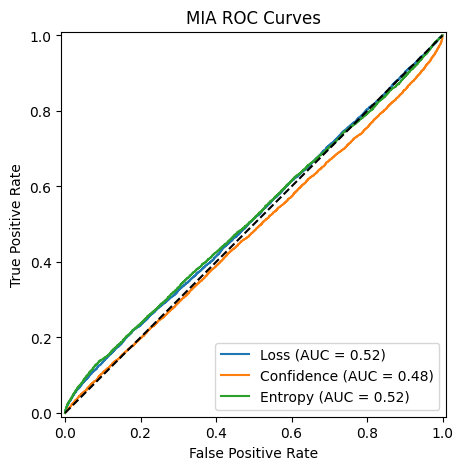

In [4]:
mia_utils.plot_mia_roc(results)